In [2]:
# 该段代码用于leNet的训练数据集MNIST的载入

from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

data_train = MNIST("./data",
                    download=True,
                    transform=transforms.Compose([
                        transforms.Resize((32, 32)),
                        transforms.ToTensor()
                    ]))
data_test = MNIST("./data",
                    train=False,
                    download=True,
                    transform=transforms.Compose([
                        transforms.Resize((32, 32)),
                        transforms.ToTensor()
                    ]))

In [3]:
data_train_loader = DataLoader(data_train, batch_size=256,
    shuffle=True, num_workers=2)
data_test_loader = DataLoader(data_test, batch_size=1024,
    num_workers=2)

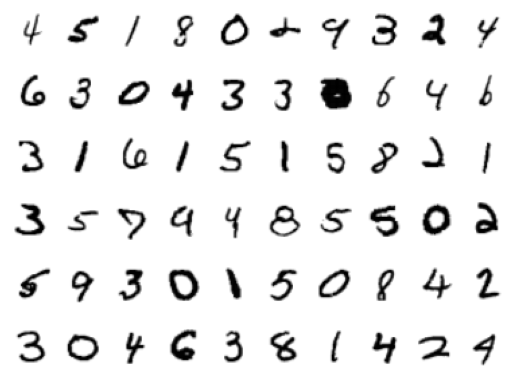

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
figure = plt.figure()
num_of_images = 60

for imgs, targets in data_train_loader:
    break

for index in range(num_of_images):
    plt.subplot(6, 10, index+1)
    plt.axis("off")
    img = imgs[index, ...]
    plt.imshow(img.numpy().squeeze(), cmap="gray_r")
plt.show()


In [5]:
# 该代码定义了LeNet模型

import torch
import torch.nn as nn

class LeNet(nn.Module):

    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 3)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 3)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc3 = nn.Linear(16*6*6, 120)
        self.fc4 = nn.Linear(120, 84)
        self.fc5 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        x = self.fc5(x)
        return x

In [6]:
model = LeNet() # 初始化实例
ret = model(torch.randn(1, 1, 32, 32)) #输入一张图片， 测试输出结果
ret.shape # torch.Size([1, 10]

torch.Size([1, 10])

In [16]:
# 该代码定义了LeNet模型的训练过程

import torch
import torch.nn as nn
# from model import LeNet # 若放入工程文件时， 需要使用此命令
import torch.optim as optim

from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

data_train = MNIST("./data",
                    download=True,
                    transform=transforms.Compose([
                        transforms.Resize((32, 32)),
                        transforms.ToTensor()
                    ]))
data_test = MNIST("./data",
                    train=False,
                    download=True,
                    transform=transforms.Compose([
                        transforms.Resize((32, 32)),
                        transforms.ToTensor()
                    ]))

data_train_loader = DataLoader(data_train, batch_size=256,
    shuffle=True, num_workers=2)
data_test_loader = DataLoader(data_test, batch_size=1024,
    num_workers=2)

model = LeNet() # 定义LeNet模型
model.train() # 切换模型到训练状态
lr = 0.01 # 定义学习率
criterion = nn.CrossEntropyLoss() #定义损失函数
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9,
    weight_decay=5e-4) #定义随机梯度下降优化器

train_loss = 0
correct = 0
total = 0

for batch_idx, (inputs, targets) in enumerate(data_train_loader):

    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()

    train_loss += loss.item()
    _, predicted = outputs.max(1)
    total += targets.size(0)
    correct += predicted.eq(targets).sum().item()

    if batch_idx % 50 == 0 or batch_idx == (len(data_train_loader)-1):
        print(batch_idx, len(data_train_loader), "Loss: %.3f | Acc: %.3f%% (%d/%d)"
        % (train_loss/(batch_idx+1), 100.*correct/total, correct, total))
        

0 235 Loss: 2.302 | Acc: 13.281% (34/256)
50 235 Loss: 2.301 | Acc: 10.654% (1391/13056)
100 235 Loss: 2.297 | Acc: 13.552% (3504/25856)
150 235 Loss: 2.279 | Acc: 20.271% (7836/38656)
200 235 Loss: 2.016 | Acc: 31.777% (16351/51456)
234 235 Loss: 1.801 | Acc: 39.093% (23456/60000)


In [15]:
# 模型的保存
torch.save(model.state_dict(), "model_lenet.pth") # 模型的状态字典

In [19]:
# 该代码定义了LeNet模型的训练过程

import torch
import torch.nn as nn
# from model import LeNet # 若放入工程文件时， 需要使用此命令
import torch.optim as optim

from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

data_train = MNIST("./data",
                    download=True,
                    transform=transforms.Compose([
                        transforms.Resize((32, 32)),
                        transforms.ToTensor()
                    ]))
data_test = MNIST("./data",
                    train=False,
                    download=True,
                    transform=transforms.Compose([
                        transforms.Resize((32, 32)),
                        transforms.ToTensor()
                    ]))

data_train_loader = DataLoader(data_train, batch_size=256,
    shuffle=True, num_workers=2)
data_test_loader = DataLoader(data_test, batch_size=1024,
    num_workers=2)

model = LeNet() # 定义LeNet模型
model.train() # 切换模型到训练状态
lr = 0.01 # 定义学习率
epochs = 4 # 定义训练轮次
criterion = nn.CrossEntropyLoss() # 定义损失函数
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9,
        weight_decay=5e-4) # 定义随机梯度下降优化器

for epoch in range(epochs):
    correct = 0
    total = 0
    train_loss = 0
    for batch_idx, (inputs, targets) in enumerate(data_train_loader):

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        if batch_idx % 50 == 0 or batch_idx == (len(data_train_loader)-1):
            print(epoch, batch_idx, len(data_train_loader), "Loss: %.3f | Acc: %.3f%% (%d/%d)"
            % (train_loss/(batch_idx+1), 100.*correct/total, correct, total))

# 模型的保存
torch.save(model.state_dict(), "model_lenet_epoch.pth") # 模型的状态字典

0 0 235 Loss: 2.306 | Acc: 9.375% (24/256)
0 50 235 Loss: 2.295 | Acc: 10.792% (1409/13056)
0 100 235 Loss: 2.249 | Acc: 24.207% (6259/25856)
0 150 235 Loss: 1.814 | Acc: 40.767% (15759/38656)
0 200 235 Loss: 1.471 | Acc: 52.194% (26857/51456)
0 234 235 Loss: 1.313 | Acc: 57.295% (34377/60000)
1 0 235 Loss: 0.370 | Acc: 87.500% (224/256)
1 50 235 Loss: 0.311 | Acc: 90.280% (11787/13056)
1 100 235 Loss: 0.282 | Acc: 91.294% (23605/25856)
1 150 235 Loss: 0.260 | Acc: 91.952% (35545/38656)
1 200 235 Loss: 0.244 | Acc: 92.388% (47539/51456)
1 234 235 Loss: 0.234 | Acc: 92.700% (55620/60000)
2 0 235 Loss: 0.140 | Acc: 95.312% (244/256)
2 50 235 Loss: 0.170 | Acc: 94.769% (12373/13056)
2 100 235 Loss: 0.160 | Acc: 94.988% (24560/25856)
2 150 235 Loss: 0.150 | Acc: 95.302% (36840/38656)
2 200 235 Loss: 0.142 | Acc: 95.546% (49164/51456)
2 234 235 Loss: 0.137 | Acc: 95.695% (57417/60000)
3 0 235 Loss: 0.097 | Acc: 96.875% (248/256)
3 50 235 Loss: 0.102 | Acc: 96.630% (12616/13056)
3 100 235 Lo

In [21]:
# 该代码定义了LeNet模型的推断过程

import torch
import torch.nn as nn
# from model import LeNet # 若放入工程文件时，需要使用此命令

# 该段代码用于leNet的训练数据集MNIST的载入

from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

data_train = MNIST("./data",
                    download=True,
                    transform=transforms.Compose([
                        transforms.Resize((32, 32)),
                        transforms.ToTensor()
                    ]))
data_test = MNIST("./data",
                    train=False,
                    download=True,
                    transform=transforms.Compose([
                        transforms.Resize((32, 32)),
                        transforms.ToTensor()
                    ]))

data_train_loader = DataLoader(data_train, batch_size=256,
    shuffle=True, num_workers=2)
data_test_loader = DataLoader(data_test, batch_size=1024,
    num_workers=2)

# 假设模型保存在model_lenet_pth文件中，也可选择多迭代期训练的模型model_lenet_epoch.pth
model_path = "./model_lenet.pth"
model = LeNet() #定义LeNet模型
criterion = nn.CrossEntropyLoss() #定义损失函数
model.load_state_dict(torch.load(model_path)) # 载入模型和参数

test_loss = 0
correct = 0
total = 0
with torch.no_grad(): # 关闭计算图
    for batch_idx, (inputs, targets) in enumerate(data_test_loader):

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        print(batch_idx, len(data_test_loader), "Loss: %.3f | Acc: %.3f%% (%d/%d)"
             % (test_loss/(batch_idx+1), 100.*correct/total, correct, total))
        

0 10 Loss: 0.299 | Acc: 89.160% (913/1024)
1 10 Loss: 0.354 | Acc: 88.330% (1809/2048)
2 10 Loss: 0.353 | Acc: 88.346% (2714/3072)
3 10 Loss: 0.362 | Acc: 87.964% (3603/4096)
4 10 Loss: 0.357 | Acc: 88.145% (4513/5120)
5 10 Loss: 0.338 | Acc: 88.835% (5458/6144)
6 10 Loss: 0.325 | Acc: 89.383% (6407/7168)
7 10 Loss: 0.315 | Acc: 89.807% (7357/8192)
8 10 Loss: 0.300 | Acc: 90.375% (8329/9216)
9 10 Loss: 0.303 | Acc: 90.350% (9035/10000)


In [22]:
# 该代码定义了LeNet模型的推断过程

import torch
import torch.nn as nn
# from model import LeNet # 若放入工程文件时，需要使用此命令

# 该段代码用于leNet的训练数据集MNIST的载入

from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

data_train = MNIST("./data",
                    download=True,
                    transform=transforms.Compose([
                        transforms.Resize((32, 32)),
                        transforms.ToTensor()
                    ]))
data_test = MNIST("./data",
                    train=False,
                    download=True,
                    transform=transforms.Compose([
                        transforms.Resize((32, 32)),
                        transforms.ToTensor()
                    ]))

data_train_loader = DataLoader(data_train, batch_size=256,
    shuffle=True, num_workers=2)
data_test_loader = DataLoader(data_test, batch_size=1024,
    num_workers=2)

# 假设模型保存在model_lenet_pth文件中，也可选择多迭代期训练的模型model_lenet_epoch.pth
model_path = "./model_lenet.pth"
model = LeNet() #定义LeNet模型
criterion = nn.CrossEntropyLoss() #定义损失函数
model.load_state_dict(torch.load(model_path)) # 载入模型和参数
model.eval() # 切换模型到测试状态

test_loss = 0
correct = 0
total = 0
with torch.no_grad(): # 关闭计算图
    for batch_idx, (inputs, targets) in enumerate(data_test_loader):

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        print(batch_idx, len(data_test_loader), "Loss: %.3f | Acc: %.3f%% (%d/%d)"
             % (test_loss/(batch_idx+1), 100.*correct/total, correct, total))
        

0 10 Loss: 0.299 | Acc: 89.160% (913/1024)
1 10 Loss: 0.354 | Acc: 88.330% (1809/2048)
2 10 Loss: 0.353 | Acc: 88.346% (2714/3072)
3 10 Loss: 0.362 | Acc: 87.964% (3603/4096)
4 10 Loss: 0.357 | Acc: 88.145% (4513/5120)
5 10 Loss: 0.338 | Acc: 88.835% (5458/6144)
6 10 Loss: 0.325 | Acc: 89.383% (6407/7168)
7 10 Loss: 0.315 | Acc: 89.807% (7357/8192)
8 10 Loss: 0.300 | Acc: 90.375% (8329/9216)
9 10 Loss: 0.303 | Acc: 90.350% (9035/10000)


In [30]:
# 该代码在LeNet模型训练过程中加入了argparse库的使用

import torch
import torch.nn as nn
import torch.optim as optim
import argparse

from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

parser=argparse.ArgumentParser(description="PyTorch LeNet Traning")

parser.add_argument ("--lr", default=0.01,type=float,help="Learning rate")

parser.add_argument ("--batch-size", "-b", default=256,type=int,help="Batchsize")

parser.add_argument ("--epoch", default=4,type=int,help="Epoch")

args=parser.parse_args(args=[])

batch_size = args.batch_size
lr = args.lr # 定义学习率
epochs = args.epoch # 定义训练迭代期
# 训练数据载入器
data_train = MNIST("./data",
                    download=True,
                    transform=transforms.Compose([
                        transforms.Resize((32, 32)),
                        transforms.ToTensor()]))
data_test = MNIST("./data",
                    train=False,
                    download=True,
                    transform=transforms.Compose([
                        transforms.Resize((32, 32)),
                        transforms.ToTensor()]))
data_train_loader = DataLoader(data_train, batch_size=batch_size,
    shuffle=True, num_workers=2)
data_test_loader = DataLoader(data_test, batch_size=batch_size,
    num_workers=2)

class LeNet(nn.Module):

    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 3)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 3)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc3 = nn.Linear(16*6*6, 120)
        self.fc4 = nn.Linear(120, 84)
        self.fc5 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        x = self.fc5(x)
        return x

def train():
    model = LeNet() # 定义LeNet模型
    model.train() # 切换模型到训练状态

    criterion = nn.CrossEntropyLoss() # 定义损失函数
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9,
                         weight_decay=5e-4) #定义随机梯度下降优化器

    for epoch in range(epochs):
        train_loss = 0
        correct = 0
        total = 0
        for batch_idx, (inputs, targets) in enumerate(data_train_loader):
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            if batch_idx % 50 == 0 or batch_idx == (len(data_train_loader) - 1):
                print(epoch, batch_idx, len(data_train_loader), "Loss: %.3f | Acc: %.3f%% (%d/%d)"
                     % (train_loss / (batch_idx + 1), 100. * correct / total, correct, total))
    # 模型的保存
    torch.save(model.state_dict(), "model_lenet_epoch.pth")  # 模型的状态字典

if __name__ == "__main__":
    train()

0 0 235 Loss: 2.305 | Acc: 11.719% (30/256)
0 50 235 Loss: 2.301 | Acc: 10.332% (1349/13056)
0 100 235 Loss: 2.298 | Acc: 12.922% (3341/25856)
0 150 235 Loss: 2.291 | Acc: 17.850% (6900/38656)
0 200 235 Loss: 2.205 | Acc: 24.738% (12729/51456)
0 234 235 Loss: 1.987 | Acc: 32.355% (19413/60000)
1 0 235 Loss: 0.535 | Acc: 85.156% (218/256)
1 50 235 Loss: 0.440 | Acc: 86.719% (11322/13056)
1 100 235 Loss: 0.412 | Acc: 87.310% (22575/25856)
1 150 235 Loss: 0.375 | Acc: 88.431% (34184/38656)
1 200 235 Loss: 0.342 | Acc: 89.517% (46062/51456)
1 234 235 Loss: 0.325 | Acc: 90.008% (54005/60000)
2 0 235 Loss: 0.149 | Acc: 95.312% (244/256)
2 50 235 Loss: 0.190 | Acc: 94.194% (12298/13056)
2 100 235 Loss: 0.176 | Acc: 94.628% (24467/25856)
2 150 235 Loss: 0.165 | Acc: 94.989% (36719/38656)
2 200 235 Loss: 0.159 | Acc: 95.186% (48979/51456)
2 234 235 Loss: 0.158 | Acc: 95.243% (57146/60000)
3 0 235 Loss: 0.108 | Acc: 97.656% (250/256)
3 50 235 Loss: 0.125 | Acc: 96.247% (12566/13056)
3 100 235 Lo